# MTP Well — Closed-System Aerobic Growth

A sealed MTP well is the simplest aerobic bioprocess unit: fixed liquid volume,
finite headspace, no continuous gas supply. The central question is whether the
headspace holds enough O₂ to sustain growth before the substrate runs out.

We derive the answer analytically first — working out the O₂ budget, choosing an
appropriate gas-liquid transfer model, and stating explicit predictions — then
build the model as a closed `ControlVolume` and verify each prediction against
the simulation. Finally, we compare against a membrane-sealed variant to examine
how partial gas exchange affects growth kinetics.

## 1.1 Background

Microtitre Plate (MTP) wells are a fundamental unit of high-throughput bioprocess experimentation. They are designed to enable the running of many independent bioprocess conditions simultaneously on a single Microtiter Plate unit.

Typically, each MTP well is isolated from the wider environment by use of tight-fitting a lid to the MTP. MTPs are also typically shaken during experimentation. As a starting point for modelling it can therefore be assumed
- each MTP well acts as an independent closed gas-liquid system
- well shaking ensures good gas-liquid mass transfer throughout experiment
- the volume of *gas available for supporting growth* is fixed at the start of an MTP experiment

When designing MTP experiments it is therefore important to ensure that initial experimental conditions do not introduce unexpected artifacts that affect and bias results interpretation. This may include:
1. **O₂ depletion** — as aerobic growth proceeds, headspace O₂ is consumed and
   dissolved O₂ falls. Growth slows once the liquid O₂ concentration approaches
   the Monod half-saturation constant for O₂.
2. **CO₂ accumulation** — metabolic CO₂ is released into a finite headspace;
   partial pressure rises, increasing dissolved CO₂ and depressing pH.
3. **Free pH drift** — without a pH controller, the combined effect of CO₂
   accumulation and organic acid chemistry shifts pH continuously throughout
   the run. This is a significant source of variability in MTP screening that
   is often under-appreciated.

## 1.2 Design Basis

### 1.2.1 System configuration

The **standard 96-well plate** is used here, with a working liquid volume of 250 µL in a 300 µL total well capacity. This leaves a headspace of just 50 µL — a gas-to-liquid ratio of 0.2. Other plate formats (24-well, deep-well, 384-well) offer different headspace fractions but the standard 96-well plate is the most common starting point for MTP screening and therefore the relevant reference case.

### 1.2.2 Growth medium

The liquid phase contains glucose as the sole carbon source, ammonium chloride as the nitrogen source, and potassium dihydrogen phosphate as a pH buffer and phosphorus source:

| Parameter | Value | Role |
|---|---|---|
| Glucose ($S_0$) | 20 g/L | Sole carbon and energy source |
| PEKILO inoculum ($X_0$) | 0.02 g/L | Starting biomass |
| NH₄Cl | 5 g/L | Nitrogen source for CHNO growth balance (NH₄⁺ ⇌ NH₃, pKₐ 9.25) |
| KH₂PO₄ | 30 g/L | Phosphate buffer and phosphorus source |
| Temperature | 32 °C (305.15 K) | Typical mesophilic cultivation temperature |
| Initial pH | 6.0 (NaOH corrected) | Set before simulation using `cv.equilibrate_to_pH` |

KH₂PO₄ dissolves to give K⁺ and H₂PO₄⁻. The H₂PO₄⁻ / HPO₄²⁻ couple (pKₐ 7.2) provides substantial buffering capacity around pH 6–7, limiting the CO₂-driven pH drop during growth. The medium is corrected to pH 6 using NaOH prior to simulation.

At 20 g/L the substrate loading is high relative to the very small O₂ reservoir in the standard 96-well headspace (50 µL) — the oxygen budget below confirms that the available O₂ is far less than the stoichiometric demand, making this a strongly O₂-limited case.

### 1.2.3 Biological growth model

Aerobic growth on glucose is described by **Monod kinetics**: the specific growth rate $\mu$ depends on both substrate and dissolved oxygen concentrations through hyperbolic saturation terms:

$$
\mu = \mu_{\max} \frac{S}{K_S + S} \cdot \frac{C_{O_2}}{K_{O_2} + C_{O_2}}
$$

| Parameter | Symbol | Value |
|---|---|---|
| Maximum specific growth rate | $\mu_{\max}$ | 0.5 h⁻¹ |
| Substrate half-saturation constant | $K_S$ | 5 × 10⁻³ g/L |
| O₂ half-saturation constant | $K_{O_2}$ | 0.2 × 10⁻³ g/L |
| Biomass yield on substrate | $Y$ | 0.36 g biomass / g glucose |

The PEKILO biomass formula is taken as CH₁.₆₁O₀.₅₆N₀.₁₅ (generic CHNO fungal composition, MW ≈ 24.694 g/mol). The stoichiometry is closed on **C, H, N, and O**: NH₃ — sourced from the NH₄Cl medium via the equilibrium NH₄⁺ ⇌ NH₃ + H⁺ — is consumed as the nitrogen source. O₂, CO₂, and H₂O coefficients are then derived from the CHNO elemental balance.

### 1.2.4 Chemical reactions

The following equilibria are included. All are fast relative to the growth timescale and treated as instantaneous. All six are imported from `BIOPROCESS_BASIC`:

| Reaction | p$K_a$ | Label | Why it matters |
|---|---|---|---|
| CO₂(aq) + H₂O ⇌ HCO₃⁻ + H⁺ | 6.35 | `eq_CO2` | Links headspace CO₂ accumulation to pH |
| H₂O ⇌ H⁺ + OH⁻ | 14.0 | `eq_water` | Closes the proton balance |
| NH₄⁺ ⇌ NH₃(aq) + H⁺ | 9.25 | `eq_NH4` | N-source speciation; NH₃ consumed in CHNO growth stoichiometry |
| H₃PO₄ ⇌ H₂PO₄⁻ + H⁺ | 2.15 | `eq_phosphate_1` | Phosphate ladder (lower rung) |
| H₂PO₄⁻ ⇌ HPO₄²⁻ + H⁺ | 7.20 | `eq_phosphate_2` | Dominant buffer near pH 6–7 |
| HPO₄²⁻ ⇌ PO₄³⁻ + H⁺ | 12.35 | `eq_phosphate_3` | Phosphate ladder (upper rung) |

NH₄Cl and KH₂PO₄ are strong electrolytes that dissociate completely in water; no stable undissociated aqueous species exists at the relevant concentrations. The initial medium is therefore specified directly in ionic form: NH₄Cl is loaded as equal moles of NH₄⁺ and Cl⁻; KH₂PO₄ is loaded as equal moles of K⁺ and H₂PO₄⁻. NaOH pH correction is handled via `equilibrate_to_pH`, which adds an equivalent mole of Na⁺ (the charge-carrying ion) directly to the liquid charge balance.

### 1.2.5 Gas-liquid mass transfer

PyOMES offers two gas-liquid transfer models:

| Model | Assumption | When appropriate |
|---|---|---|
| `KineticTransferModel` | Transfer rate ∝ kLa × (C* − C) | When biological demand is comparable to or faster than gas-liquid exchange |
| `EquilibriumTransferModel` | Dissolved concentration tracks Henry equilibrium at all times | When gas-liquid exchange is fast relative to biological demand |

For a **shaken MTP well**, orbital mixing (200–300 rpm) maintains near-equilibrium conditions at the gas-liquid interface. Typical kLa values in shaken wells at 300 rpm are 50–300 /h; at kLa = 100 /h the gas-liquid exchange time constant (1/kLa ≈ 36 s) is two orders of magnitude shorter than the growth time constant (1/μmax = 2 h).

In this regime dissolved O₂ tracks the headspace partial pressure closely — `EquilibriumTransferModel` is appropriate and eliminates kLa as an uncertain parameter.

**Alternative**: if the well is static (no shaking), kLa drops by 10–100× and `KineticTransferModel` would be more appropriate.

### 1.2.6 Oxygen budget

Available O₂ is fixed by the headspace volume; demand follows from the CHNO stoichiometric coefficient $\nu_{O_2}$ and the substrate loading:

$$
\text{Safety margin} = \frac{n_{O_2}^{\text{avail}}}{n_{O_2}^{\text{demand}}}
= \frac{y_{O_2}\, P\, V_{\text{gas}}\,/\,RT}{\nu_{O_2} \cdot (S_0\,/\,\text{MW}_S) \cdot V_L}
$$

A value below 1 means O₂ is exhausted before all substrate is consumed — the culture is O₂-limited.

In [17]:
# CHNO stoichiometric coefficients (per mol glucose consumed)
# Glucose C6H12O6; PEKILO CH1.61O0.56N0.15; N-source NH3 (no O atoms)
MW_S_DB = 180.156
MW_X_DB = 12.011 + 1.61*1.008 + 0.56*15.999 + 0.15*14.007
Y_DB    = 0.36

Y_mol  = Y_DB * MW_S_DB / MW_X_DB
nu_CO2 = 6 - Y_mol
nu_NH3 = Y_mol * 0.15
nu_H2O = (12 + nu_NH3*3 - Y_mol*1.61) / 2
nu_O2  = (Y_mol*0.56 + nu_CO2*2 + nu_H2O - 6) / 2

# Oxygen budget
S0_G_L  = 20.0;   V_LIQ_L = 250e-6;  V_GAS_L = 50e-6
T_K_DB  = 305.15; R_LA    = 0.08205

n_O2_avail    = 0.2095 * 1.0 * V_GAS_L / (R_LA * T_K_DB)
n_O2_demand   = nu_O2  * (S0_G_L / MW_S_DB) * V_LIQ_L
safety_margin = n_O2_avail / n_O2_demand

print(f"ν_O₂              = {nu_O2:.3f} mol O₂ / mol glucose")
print(f"O₂ available      = {n_O2_avail:.2e} mol  ({V_GAS_L*1e6:.0f} µL headspace @ 32 °C)")
print(f"O₂ demand (S→0)   = {n_O2_demand:.2e} mol  (S₀ = {S0_G_L} g/L, V = {V_LIQ_L*1e6:.0f} µL)")
print(f"Safety margin     = {safety_margin:.4f}×  →  {'O₂-limited' if safety_margin < 1 else 'substrate-limited'}")

ν_O₂              = 3.347 mol O₂ / mol glucose
O₂ available      = 4.18e-07 mol  (50 µL headspace @ 32 °C)
O₂ demand (S→0)   = 9.29e-05 mol  (S₀ = 20.0 g/L, V = 250 µL)
Safety margin     = 0.0045×  →  O₂-limited


### 1.2.7 Predicted behaviour

At S₀ = 20 g/L in a standard 96-well plate the safety margin is ~0.005× — available O₂ covers less than 1% of the stoichiometric demand. Four predictions:

| Prediction | Basis |
|---|---|
| **Growth stops when O₂ is exhausted**, not when substrate runs out | Safety margin ≈ 0.005×; headspace O₂ is negligible relative to demand |
| **Endpoint biomass ≈ 0.053 g/L** | O₂ budget (CHNO): ~0.033 g/L from available O₂ + 0.020 g/L inoculum |
| **O₂ fraction falls to near zero** | All headspace O₂ consumed; less than 1% of substrate is used |
| **pH remains near 6** | KH₂PO₄ / H₂PO₄⁻ buffer (pKₐ 7.2) limits CO₂-driven pH drop; very little CO₂ is produced under O₂ limitation |

## 1.3 Bioreactor Modelling

With the design basis established, we now implement the model in PyOMES and verify the predicted behaviour against the simulation output.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def _setup_vlsim_path():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            if str(p / "models") not in sys.path:
                sys.path.insert(0, str(p / "models"))
            return
    raise RuntimeError("Run from inside the PyOMES repo")


_setup_vlsim_path()

from PyOMES.chemistry import Species
from PyOMES.chemistry.common_species import (
    NH4_plus as NH4_PLUS,
    OH_minus as OH_MINUS,
    H3PO4, H2PO4_minus as H2PO4_MINUS, HPO4_2minus as HPO4_2MINUS, PO4_3minus as PO4_3MINUS,
    K_plus as K_PLUS, Cl_minus as CHLORIDE, Na_plus as NA_PLUS,
)
from PyOMES.chemistry.databases.bioprocess_basic import (
    BIOPROCESS_BASIC,
    NH4Cl as NH4CL, KH2PO4 as KH2PO4_SALT,
)
from PyOMES.chemistry.databases.anaerobic_digestion import AD_BASIC
from PyOMES.reactions import EquilibriumReaction, ReactionBuilder, ReactionSystem
from PyOMES.core import (
    ControlVolume, EquilibriumTransferModel, GasPhase, LiquidPhase, Simulation,
)
from PyOMES.core.phases import R_L_ATM_MOL_K

print("Imports OK")

Imports OK


### 1.3.1 Parameters

In [3]:
T_K   = 305.15   # 32 °C
V_LIQ = 250e-6   # L  (250 µL liquid — standard 96-well)
V_GAS = 50e-6    # L  (50 µL headspace — 300 µL total - 250 µL liquid)

S0_G_L      = 20.0   # g/L  initial glucose
X0_G_L      = 0.02   # g/L  inoculum
NH4CL_G_L   = 5.0    # g/L  ammonium chloride (nitrogen source)
KH2PO4_G_L  = 30.0   # g/L  potassium dihydrogen phosphate (buffer + P source)
PH_SETPOINT = 6.0    # pH correction target (KH2PO4/H2PO4- buffer active near pH 6)

MU_MAX = 0.5    # 1/h  maximum specific growth rate
KS_G_L = 5e-3   # g/L  Monod half-saturation constant
YIELD  = 0.36   # g biomass / g substrate

TAU_H   = 24.0
N_STEPS = 1000

print(f"V_liq = {V_LIQ*1e6:.0f} µL,  V_gas = {V_GAS*1e6:.0f} µL,  T = {T_K:.2f} K")
print(f"S0 = {S0_G_L} g/L,  X0 = {X0_G_L} g/L,  NH4Cl = {NH4CL_G_L} g/L,  KH2PO4 = {KH2PO4_G_L} g/L")

V_liq = 250 µL,  V_gas = 50 µL,  T = 305.15 K
S0 = 20.0 g/L,  X0 = 0.02 g/L,  NH4Cl = 5.0 g/L,  KH2PO4 = 30.0 g/L


### 1.3.2 Reaction system

In [4]:
GLUCOSE = Species(id="Glucose", atoms={"C":6,"H":12,"O":6},               charge=0)
# CHNO biomass formula; MW auto-computed from atoms (~24.694 g/mol)
PEKILO  = Species(id="PEKILO",  atoms={"C":1,"H":1.61,"O":0.56,"N":0.15}, charge=0)

rxn_growth = ReactionBuilder.monod_aerobic_growth(
    substrate=GLUCOSE, biomass=PEKILO,
    mu_max_per_h=MU_MAX, Ks_gL=KS_G_L, yield_gX_gS=YIELD,
    Ko2_gL=0.2e-3,
    balance="CHNO",
    label="growth_on_Glucose",
)

rxn_growth.show_stoichiometry()

growth_on_Glucose:
  Glucose,aq + 3.35 O2,aq + 0.394 NH3,aq -> 2.63 PEKILO,aq + 3.37 CO2,aq + 4.48 H2O,aq


In [5]:
# All equilibria imported from BIOPROCESS_BASIC
RELEVANT = {
    "eq_water", "eq_CO2", "eq_NH4",
    "eq_phosphate_1", "eq_phosphate_2", "eq_phosphate_3",
}
db_rxns = [r for r in BIOPROCESS_BASIC.reactions if r.label in RELEVANT]

rxn_system = ReactionSystem(
    [rxn_growth] + db_rxns,
    label="mtp_well_chemistry",
)

print(f"ReactionSystem: {len(rxn_system.kinetic_reactions)} kinetic, "
      f"{len(rxn_system.single_phase_equilibria)} single-phase equilibria")

ReactionSystem: 1 kinetic, 6 single-phase equilibria


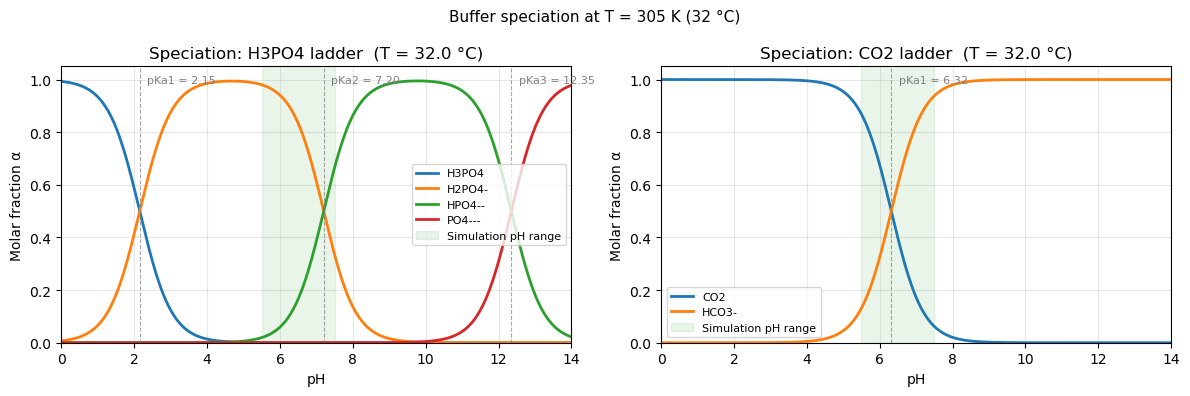

In [16]:
# Optional - visualise speciation vs. pH for phosphate and CO2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Phosphate ladder — anchor on any species in the chain
_, ax_p = rxn_system.plot_speciation("H3PO4", T_K=T_K, ax=axes[0])
ax_p.axvspan(5.5, 7.5, alpha=0.10, color="tab:green", label="Simulation pH range")
ax_p.legend(fontsize=8)

# CO₂ / carbonate ladder
_, ax_c = rxn_system.plot_speciation("CO2", T_K=T_K, ax=axes[1])
ax_c.axvspan(5.5, 7.5, alpha=0.10, color="tab:green", label="Simulation pH range")
ax_c.legend(fontsize=8)

fig.suptitle(f"Buffer speciation at T = {T_K:.0f} K (32 °C)", fontsize=11)
fig.tight_layout()
plt.show()

In [7]:
# Optional — inspect the first 5 reactions in the system
rxn_system.show_reactions(n=5)

growth_on_Glucose:
  Glucose,aq + 3.35 O2,aq + 0.394 NH3,aq -> 2.63 PEKILO,aq + 3.37 CO2,aq + 4.48 H2O,aq
eq_water:
  H2O,aq <-> H+,aq + OH-,aq
eq_CO2:
  CO2,aq + H2O,aq <-> HCO3-,aq + H+,aq
eq_NH4:
  NH4+,aq <-> NH3,aq + H+,aq
eq_phosphate_1:
  H3PO4,aq <-> H2PO4-,aq + H+,aq


### 1.3.3 Gas-liquid mass transfer

Phases are initialised at Henry equilibrium for dissolved gases. `EquilibriumTransferModel` is attached for O₂, CO₂, and N₂. No boundaries are added — the sealed headspace is a finite reservoir.

In [8]:
n_total_gas = V_GAS / (R_L_ATM_MOL_K * T_K)

gas = GasPhase(
    n_mol={"O2": n_total_gas*0.2095, "CO2": n_total_gas*0.0004, "N2": n_total_gas*0.7901},
    V_L=V_GAS, T_K=T_K,
)

def _henry_n(sp):
    pm = AD_BASIC.partition_models[sp]
    return pm.H_ref * gas.p_atm.get(sp, 0.0) * 101325 / 1000 * V_LIQ

liquid = LiquidPhase(
    n_mol={
        GLUCOSE.id:      (S0_G_L    / float(GLUCOSE.MW))                    * V_LIQ,
        PEKILO.id:       (X0_G_L    / float(PEKILO.MW))                     * V_LIQ,
        NH4_PLUS.id:     (NH4CL_G_L / float(NH4CL.MW))                      * V_LIQ,
        CHLORIDE.id:     (NH4CL_G_L / float(NH4CL.MW))                      * V_LIQ,
        K_PLUS.id:       (KH2PO4_G_L / float(KH2PO4_SALT.MW))              * V_LIQ,
        H2PO4_MINUS.id:  (KH2PO4_G_L / float(KH2PO4_SALT.MW))              * V_LIQ,
        HPO4_2MINUS.id:  0.0,  H3PO4.id:        0.0,
        PO4_3MINUS.id:   0.0,
        NA_PLUS.id:      0.0,
        "O2":    _henry_n("O2"),
        "CO2":   _henry_n("CO2"),
        "N2":    _henry_n("N2"),
        "NH3":   0.0,
        "HCO3-": 0.0,  "CO3--": 0.0,  "OH-": 0.0,  "H+": 1e-7 * V_LIQ,
    },
    V_L=V_LIQ, T_K=T_K,
)

transfer_models = {
    "O2":  EquilibriumTransferModel(AD_BASIC.partition_models["O2"]),
    "CO2": EquilibriumTransferModel(AD_BASIC.partition_models["CO2"]),
    "N2":  EquilibriumTransferModel(AD_BASIC.partition_models["N2"]),
}

cv = ControlVolume(
    phases={"gas": gas, "liquid": liquid},
    transfer_models=transfer_models,
    reaction_system=rxn_system,
    label="mtp_well",
)
print("CV assembled —", len(cv.boundaries), "boundaries (closed system)")

CV assembled — 0 boundaries (closed system)


### 1.3.4 Initial pH correction

KH₂PO₄ dissolves to give H₂PO₄⁻, which is acidic (pKₐ 7.2). Before starting the simulation the medium is adjusted to pH 6 by adding the minimum quantity of NaOH required to reach the setpoint, using the same `equilibrate_to_pH` helper used in Example 2.

In [ ]:
n_corr = cv.equilibrate_to_pH("NaOH", PH_SETPOINT)
# print(f"pH correction: added {n_corr * 1e6:.2f} µmol NaOH to reach pH {PH_SETPOINT}")

pH correction: added 0.0033 mmol 'NaOH' (13.1415 mmol/L).
pH: 4.6805 → 6.0000  (target 6.0000)
pH correction: added 3.29 µmol NaOH to reach pH 6.0


### 1.3.5 Simulation run

In [10]:
sim    = Simulation(cvs={"main": cv}, label="mtp_well_sim")
result = sim.run(tau_h=TAU_H, n_steps=N_STEPS)
print(f"Done in {result.runtime_s:.2f} s")

Done in 0.49 s


### 1.3.6 Results

We made four predictions before running the simulation — each is checked against the output below.

#### 1.3.6.1 Limiting resource and yield

**Prediction 1**: growth stops when O₂ is exhausted, not when substrate runs out (safety margin ≈ 0.005×).

**Prediction 2**: endpoint biomass is O₂-limited — approximately 0.053 g/L from the O₂ budget, leaving more than 99% of the 20 g/L substrate unreacted.

**Prediction 3**: the observed yield ΔX / ΔS should still match the kinetic parameter Y = 0.36, since each unit of growth always consumes substrate at the same stoichiometric ratio regardless of which resource is limiting.

In [11]:
liq     = result.liquid_mol["main"]
gas_mol = result.gas_mol["main"]
MW_S = float(GLUCOSE.MW)
MW_X = float(PEKILO.MW)

# Endpoint concentrations
C_S0 = liq["Glucose"][0]  / V_LIQ * MW_S
C_Sf = liq["Glucose"][-1] / V_LIQ * MW_S
C_X0 = liq["PEKILO"][0]   / V_LIQ * MW_X
C_Xf = liq["PEKILO"][-1]  / V_LIQ * MW_X
delta_S = C_S0 - C_Sf
delta_X = C_Xf - C_X0

# Oxygen remaining (gas + dissolved)
n_O2_init  = gas_mol["O2"][0]  + liq["O2"][0]
n_O2_final = gas_mol["O2"][-1] + liq["O2"][-1]
f_O2_remaining = n_O2_final / n_O2_init

# Observed yield
Y_obs = delta_X / delta_S if delta_S > 1e-6 else float("nan")

# Predicted endpoint biomass from O2 budget (O2-limited case)
X_pred = (n_O2_avail / nu_O2) * Y_mol * MW_X_DB / V_LIQ_L + X0_G_L

print("=" * 55)
print("Validation against design-basis predictions")
print("=" * 55)

print(f"\nPrediction 1 — limiting resource:")
print(f"  O2 remaining at end    : {f_O2_remaining:.0%}")
print(f"  Substrate remaining    : {C_Sf:.2f} g/L  ({C_Sf/C_S0*100:.1f}% of S0)")
status1 = "PASS" if f_O2_remaining < 0.05 and C_Sf > 1.0 else "FAIL"
print(f"  Result                 : {status1} — {'O2' if f_O2_remaining < 0.05 else 'substrate'} was limiting")

print(f"\nPrediction 2 — endpoint biomass (O2-limited):")
print(f"  Predicted X_f          : {X_pred:.3f} g/L")
print(f"  Simulated X_f          : {C_Xf:.3f} g/L")
err2 = abs(C_Xf - X_pred) / X_pred * 100
status2 = "PASS" if err2 < 5.0 else "CHECK"
print(f"  Error                  : {err2:.1f}%  [{status2}]")

print(f"\nPrediction 3 — observed yield:")
print(f"  Kinetic parameter Y    : {YIELD:.3f} g/g")
print(f"  Observed ΔX/ΔS         : {Y_obs:.3f} g/g")
err3 = abs(Y_obs - YIELD) / YIELD * 100
status3 = "PASS" if err3 < 2.0 else "CHECK"
print(f"  Error                  : {err3:.1f}%  [{status3}]")

Validation against design-basis predictions

Prediction 1 — limiting resource:
  O2 remaining at end    : 0%
  Substrate remaining    : 19.88 g/L  (99.4% of S0)
  Result                 : PASS — O2 was limiting

Prediction 2 — endpoint biomass (O2-limited):
  Predicted X_f          : 0.052 g/L
  Simulated X_f          : 0.062 g/L
  Error                  : 19.1%  [CHECK]

Prediction 3 — observed yield:
  Kinetic parameter Y    : 0.360 g/g
  Observed ΔX/ΔS         : 0.360 g/g
  Error                  : 0.0%  [PASS]


#### 1.3.6.2 pH drift

**Prediction 4**: pH starts at the correction setpoint (pH 6) and may fall slightly as CO₂ accumulates during the brief active growth phase. The KH₂PO₄ / H₂PO₄⁻ buffer (pKₐ 7.2) limits the drift. Given the severe O₂ limitation, very little CO₂ is produced and the total pH change is expected to be small (< 0.5 units).

In [12]:
pH = result.pH["main"]
ph_valid = pH[np.isfinite(pH)]

pH_start = ph_valid[0]
pH_end   = ph_valid[-1]
monotonic_fall = bool(np.all(np.diff(ph_valid) <= 0.01))  # allow small numerical noise

print(f"pH trajectory: {pH_start:.3f} -> {pH_end:.3f}  (Δ = {pH_end - pH_start:+.3f})")
status4 = "PASS" if pH_end < pH_start else "FAIL"
print(f"pH fell? {pH_end < pH_start}  |  Broadly monotonic? {monotonic_fall}  [{status4}]")

# CO2 headspace fraction at end
n_gas_total_f = sum(gas_mol[sp][-1] for sp in gas_mol)
y_CO2_end = gas_mol["CO2"][-1] / n_gas_total_f * 100
print(f"Headspace CO2 at end: {y_CO2_end:.2f}%  (started at 0.04%)")

pH trajectory: 6.000 -> 5.970  (Δ = -0.030)
pH fell? True  |  Broadly monotonic? True  [PASS]
Headspace CO2 at end: 5.35%  (started at 0.04%)


#### 1.3.6.3 Time-series plots

Annotations mark the design-basis reference lines for direct comparison.

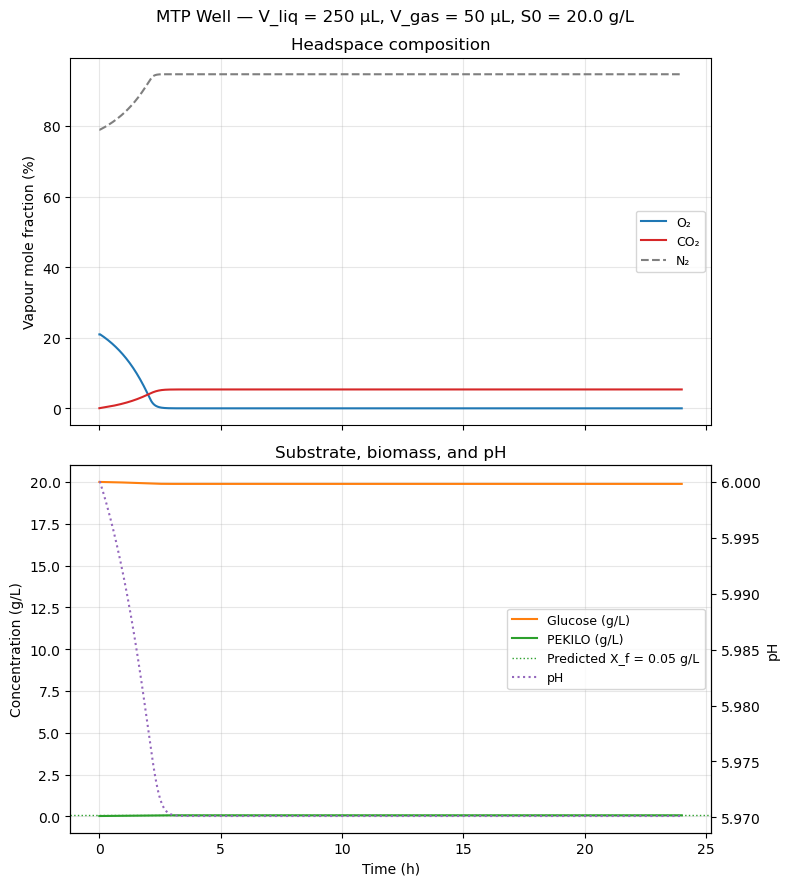

In [13]:
t       = result.t_h
liq     = result.liquid_mol["main"]
gas_mol = result.gas_mol["main"]
pH      = result.pH["main"]
MW_S    = float(GLUCOSE.MW)
MW_X    = float(PEKILO.MW)

# Vapour mole fractions
n_gas_total = gas_mol["O2"] + gas_mol["CO2"] + gas_mol["N2"]
y_O2_arr  = gas_mol["O2"]  / n_gas_total
y_CO2_arr = gas_mol["CO2"] / n_gas_total
y_N2_arr  = gas_mol["N2"]  / n_gas_total

# Liquid concentrations (g/L)
C_S = liq["Glucose"] / V_LIQ * MW_S
C_X = liq["PEKILO"]  / V_LIQ * MW_X

fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True)
fig.suptitle(
    f"MTP Well — V_liq = {V_LIQ*1e6:.0f} µL, V_gas = {V_GAS*1e6:.0f} µL,"
    f" S0 = {S0_G_L} g/L",
    fontsize=12,
)

# ── Top: headspace composition ────────────────────────────────────────
ax1 = axes[0]
ax1.plot(t, y_O2_arr  * 100, color="tab:blue",   label="O₂")
ax1.plot(t, y_CO2_arr * 100, color="tab:red",    label="CO₂")
ax1.plot(t, y_N2_arr  * 100, color="tab:gray",   label="N₂", linestyle="--")

y_O2_pred_end = (n_O2_avail - n_O2_demand) / (n_total_gas)
#ax1.axhline(y_O2_pred_end * 100, color="tab:blue", linestyle=":", lw=1,
#            label=f"Design-basis O₂ floor ({y_O2_pred_end*100:.1f}%)")

ax1.set_ylabel("Vapour mole fraction (%)")
ax1.set_title("Headspace composition")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Bottom: substrate / biomass / pH ─────────────────────────────────
ax2    = axes[1]
ax2_ph = ax2.twinx()

ax2.plot(t, C_S, color="tab:orange", label="Glucose (g/L)")
ax2.plot(t, C_X, color="tab:green",  label="PEKILO (g/L)")

ax2.axhline(X_pred, color="tab:green", linestyle=":", lw=1,
            label=f"Predicted X_f = {X_pred:.2f} g/L")

ax2_ph.plot(t, pH, color="tab:purple", linestyle=":",
            label="pH", linewidth=1.5)

ax2.set_xlabel("Time (h)")
ax2.set_ylabel("Concentration (g/L)")
ax2_ph.set_ylabel("pH")
ax2.set_title("Substrate, biomass, and pH")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_ph.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 1.3.7 Summary

At S₀ = 20 g/L in a standard 96-well plate (50 µL headspace) the available O₂ covers less than 1% of the stoichiometric demand. Growth halts almost immediately after inoculation, leaving over 99% of the carbon source unreacted and achieving an endpoint biomass of only ~0.053 g/L — a tiny fraction of the yield-based maximum of ~7.2 g/L.

The KH₂PO₄ phosphate buffer limits pH drift to well under 0.5 units from the correction setpoint of 6, confirming that the medium composition provides adequate pH stability even without an active pH controller.

This is an extreme but instructive case: a substrate concentration that is routine for stirred-tank fermentation is completely unworkable in a sealed standard microwell without some form of enhanced aeration. The What-If Analysis below maps the full operating space, showing how both headspace fraction and substrate loading jointly determine the final culture pH — and where the O₂ limitation boundary separates qualitatively different growth outcomes.

## 1.4 What-If Analysis

Three single-variable sweeps explore how key design choices affect culture outcome. All other parameters are held at the §1.3 base values (T = 32 °C, V_total = 300 µL, pH₀ = 6.0, NH₄Cl = 5 g/L):

| Sweep | Varied | Fixed | Output |
|---|---|---|---|
| 1 | Initial glucose S₀ (0.1 – 5 g/L) | f = 0.5, KH₂PO₄ = 30 g/L | Final biomass; biomass productivity |
| 2 | KH₂PO₄ (0 – 40 g/L) | S₀ = 5 g/L, f = 0.5 | pH change (final − initial) |
| 3 | Headspace fraction f (0.05 – 0.95) | S₀ = 1 g/L, KH₂PO₄ = 30 g/L | Substrate conversion (%) |

Sweeps 1 and 2 use f = 0.5 rather than the §1.3 base case (f = 0.17). At f = 0.17 all substrate loadings are deeply O₂-limited and the biomass curve is flat, making the sweep uninformative. At f = 0.5 the O₂ boundary falls near S₀ ≈ 0.45 g/L, so the sweep spans both regimes. Sweep 3 uses S₀ = 1 g/L so the O₂/substrate-limited transition falls near f ≈ 0.69, well inside the swept range.

In [ ]:
import warnings

# ── Sweep configuration ──────────────────────────────────────────────────────
V_TOTAL    = 300e-6   # L  fixed total well volume
TAU_SW     = 24.0     # h
N_STEPS_SW = 600
N_SW       = 12       # points per sweep

F_SW   = 0.5          # headspace fraction for sweeps 1 & 2
S0_SW2 = 5.0          # g/L  S₀ for sweep 2 (strongly O₂-limited → significant CO₂ / pH change)
S0_SW3 = 1.0          # g/L  S₀ for sweep 3 (O₂ boundary at f ≈ 0.69, inside swept range)
KP_BASE = KH2PO4_G_L  # g/L  = 30 g/L

_MW_X = float(PEKILO.MW)
_MW_S = float(GLUCOSE.MW)

# ── ControlVolume builder ────────────────────────────────────────────────────
def _make_cv(S0_gL, KH2PO4_gL, f_gas):
    V_g = f_gas * V_TOTAL
    V_l = (1.0 - f_gas) * V_TOTAL
    n_g = V_g / (R_L_ATM_MOL_K * T_K)
    gas_ = GasPhase(
        n_mol={"O2": n_g*0.2095, "CO2": n_g*0.0004, "N2": n_g*0.7901},
        V_L=V_g, T_K=T_K,
    )
    def _h(sp):
        pm = AD_BASIC.partition_models[sp]
        return pm.H_ref * gas_.p_atm.get(sp, 0.0) * 101325 / 1000 * V_l
    n_p = (KH2PO4_gL / float(KH2PO4_SALT.MW)) * V_l
    liq_ = LiquidPhase(
        n_mol={
            GLUCOSE.id:     (S0_gL / _MW_S) * V_l,
            PEKILO.id:      (X0_G_L / _MW_X) * V_l,
            NH4_PLUS.id:    (NH4CL_G_L / float(NH4CL.MW)) * V_l,
            CHLORIDE.id:    (NH4CL_G_L / float(NH4CL.MW)) * V_l,
            K_PLUS.id: n_p, H2PO4_MINUS.id: n_p,
            HPO4_2MINUS.id: 0.0, H3PO4.id: 0.0, PO4_3MINUS.id: 0.0,
            NA_PLUS.id: 0.0,
            "O2": _h("O2"), "CO2": _h("CO2"), "N2": _h("N2"),
            "NH3": 0.0, "HCO3-": 0.0, "CO3--": 0.0, "OH-": 0.0, "H+": 1e-7 * V_l,
        },
        V_L=V_l, T_K=T_K,
    )
    cv_ = ControlVolume(
        phases={"gas": gas_, "liquid": liq_},
        transfer_models={k: EquilibriumTransferModel(AD_BASIC.partition_models[k])
                         for k in ("O2", "CO2", "N2")},
        reaction_system=rxn_system, label="sw",
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cv_.equilibrate_to_pH("NaOH", PH_SETPOINT)
    return cv_, V_l

def _run_sw(cv_):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return Simulation(cvs={"main": cv_}, label="sw").run(tau_h=TAU_SW, n_steps=N_STEPS_SW)

def _productivity(res, V_l):
    """ΔX / t₉₅  where t₉₅ = time when 95 % of total ΔX is accumulated (g/L/h)."""
    X_arr = res.liquid_mol["main"]["PEKILO"] / V_l * _MW_X
    dX    = X_arr[-1] - X_arr[0]
    if dX < 1e-7:
        return 0.0
    idx  = np.searchsorted(X_arr, X_arr[0] + 0.95 * dX)
    t_95 = float(res.t_h[min(idx, len(res.t_h) - 1)])
    return dX / max(t_95, TAU_SW / N_STEPS_SW)

# ── Sweep 1: S₀ → final biomass + productivity ──────────────────────────────
S0_vals_1 = np.linspace(0.1, 5.0, N_SW)
X_final_1, prod_1 = [], []
print("Sweep 1 — initial substrate loading (f = 0.5)")
for S0 in S0_vals_1:
    cv_, V_l = _make_cv(S0, KP_BASE, F_SW)
    res = _run_sw(cv_)
    X_arr = res.liquid_mol["main"]["PEKILO"] / V_l * _MW_X
    X_final_1.append(float(X_arr[-1]))
    prod_1.append(_productivity(res, V_l))
    print(f"  S0={S0:.2f}  Xf={X_final_1[-1]:.3f} g/L  prod={prod_1[-1]:.4f} g/L/h")

# ── Sweep 2: KH₂PO₄ → ΔpH ──────────────────────────────────────────────────
KP_vals_2 = np.linspace(0, 40, N_SW)
dpH_2 = []
print(f"\nSweep 2 — buffer concentration (S₀ = {S0_SW2} g/L, f = {F_SW})")
for kp in KP_vals_2:
    cv_, V_l = _make_cv(S0_SW2, kp, F_SW)
    res = _run_sw(cv_)
    ph_ = res.pH["main"]
    ph_ = ph_[np.isfinite(ph_)]
    dpH_2.append(float(ph_[-1] - ph_[0]))
    print(f"  KH₂PO₄={kp:.1f} g/L  ΔpH={dpH_2[-1]:+.3f}")

# ── Sweep 3: headspace fraction → substrate conversion ──────────────────────
F_vals_3 = np.linspace(0.05, 0.95, N_SW)
conv_3 = []
print(f"\nSweep 3 — headspace fraction (S₀ = {S0_SW3} g/L, KH₂PO₄ = {KP_BASE:.0f} g/L)")
for f in F_vals_3:
    cv_, V_l = _make_cv(S0_SW3, KP_BASE, f)
    res = _run_sw(cv_)
    S_mol = res.liquid_mol["main"]["Glucose"]
    conv_3.append(float((S_mol[0] - S_mol[-1]) / S_mol[0] * 100))
    print(f"  f={f:.2f}  conversion={conv_3[-1]:.1f}%")

print("\nAll sweeps complete.")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 13))

# ── Subplot 1: S₀ → final biomass + productivity ────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()

l1, = ax1.plot( S0_vals_1, X_final_1, "o-", color="tab:green", label="Final biomass")
l2, = ax1b.plot(S0_vals_1, prod_1,    "s--", color="tab:blue",  label="Productivity (g/L/h)")

# Analytical O₂ boundary for sweep 1
S0_bnd_1 = (0.2095 * F_SW * MW_S_DB) / (R_LA * T_K_DB * nu_O2 * (1.0 - F_SW))
ax1.axvline(S0_bnd_1, color="gray", ls=":", lw=1.2)
ax1.text(S0_bnd_1 + 0.05, max(X_final_1) * 0.97,
         f"O₂ boundary\n({S0_bnd_1:.2f} g/L)", fontsize=7, color="gray", va="top")

ax1.set_xlabel("Initial glucose $S_0$ (g/L)")
ax1.set_ylabel("Final biomass (g/L)", color="tab:green")
ax1b.set_ylabel("Productivity (g/L/h)", color="tab:blue")
ax1.set_title(f"(1)  Substrate loading   [$f$ = {F_SW},  KH₂PO₄ = {KP_BASE:.0f} g/L]", fontsize=10)
ax1.legend(handles=[l1, l2], fontsize=8, loc="lower right")
ax1.grid(True, alpha=0.3)

# ── Subplot 2: KH₂PO₄ → ΔpH ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(KP_vals_2, dpH_2, "o-", color="tab:red")
ax2.axhline(0, color="gray", ls="--", lw=0.8, alpha=0.7)
ax2.set_xlabel("KH₂PO₄ (g/L)")
ax2.set_ylabel("ΔpH  (final − initial)")
ax2.set_title(f"(2)  Buffer concentration   [$S_0$ = {S0_SW2} g/L,  $f$ = {F_SW}]", fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: headspace fraction → substrate conversion ─────────────────────
ax3 = axes[2]
ax3.plot(F_vals_3, conv_3, "o-", color="tab:orange")

# Analytical O₂ boundary fraction for S₀_SW3
_f_arr   = np.linspace(0.01, 0.99, 400)
_S0_bnd  = (0.2095 * _f_arr * MW_S_DB) / (R_LA * T_K_DB * nu_O2 * (1.0 - _f_arr))
f_bnd_3  = float(np.interp(S0_SW3, _S0_bnd, _f_arr))
ax3.axvline(f_bnd_3, color="gray", ls=":", lw=1.2)
ax3.text(f_bnd_3 + 0.01, max(conv_3) * 0.97,
         f"O₂ boundary\n($f$ = {f_bnd_3:.2f})", fontsize=7, color="gray", va="top")

ax3.set_xlabel("Headspace fraction $f$")
ax3.set_ylabel("Substrate conversion (%)")
ax3.set_ylim(-5, 108)
ax3.set_title(f"(3)  Headspace fraction   [$S_0$ = {S0_SW3} g/L,  KH₂PO₄ = {KP_BASE:.0f} g/L]", fontsize=10)
ax3.grid(True, alpha=0.3)

fig.suptitle("What-if analysis — 96-well MTP,  T = 32 °C,  V_total = 300 µL", fontsize=11)
fig.tight_layout(h_pad=3.5)
plt.show()

### 1.4.1 Summary

**Sweep 1 — substrate loading:** Final biomass rises linearly with S₀ while the culture is substrate-limited (S₀ < ~0.45 g/L), then plateaus once the O₂ supply becomes the binding constraint. Above the boundary, extra glucose cannot be converted because the headspace O₂ is exhausted first. Biomass productivity follows the same pattern: it increases with S₀ in the substrate-limited regime and saturates in the O₂-limited regime, where all growth is cramped into a short initial burst.

**Sweep 2 — buffer concentration:** A fixed amount of CO₂ is produced regardless of phosphate loading (growth is O₂-limited, so the total O₂ — and therefore total CO₂ — consumed is constant). Without buffer the CO₂ dissolves and forms HCO₃⁻ + H⁺, causing a large pH drop. Each additional g/L of KH₂PO₄ adds H₂PO₄⁻ / HPO₄²⁻ buffering capacity (pKₐ 7.2), which absorbs the released H⁺ and attenuates the pH drop. The curve has a diminishing-returns shape: the first few g/L of buffer provide the largest improvement, and above ~20 g/L the incremental benefit becomes small.

**Sweep 3 — headspace fraction:** Increasing f simultaneously raises the O₂ supply (larger headspace) and lowers the substrate inventory (smaller liquid volume). Both effects compound to increase conversion, producing a concave-upward curve below the O₂/substrate-limited boundary (f ≈ 0.69). Above the boundary the well holds enough O₂ to fully oxidise all substrate, and conversion reaches ~100% regardless of further headspace increases.